# Week 5 Assignment - Text Generation with RNN, LSTM and GRU

Name: Deeptesh Mohapatra

Corpus: the Shakespeare text used in the TensorFlow tutorials (about 1.1 million characters).

Goal: build a deep learning model that learns the structure, grammar and context of a text
corpus and can then generate new, coherent looking text. I do this at the character level and
compare three recurrent architectures - a vanilla RNN, an LSTM and a GRU - on the same data.

Plan:

1. Load the text and look at it
2. Preprocess it into character sequences (predict the next character from the previous ones)
3. Build and train three models: SimpleRNN, LSTM and GRU
4. Compare how they train (loss, accuracy, time)
5. Generate text with each model and see which reads best
6. Show how the sampling temperature changes the output
7. Write up what I found

Why character level: the model reads one character at a time and learns to predict the next
one. If it learns well it picks up spelling, spacing, punctuation, and the play style of names
in capitals followed by a colon - all without being told any of the rules.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Loading the text

Keras can fetch the Shakespeare corpus directly (it caches after the first download).

In [2]:
path = keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')
text = open(path, 'r', encoding='utf-8').read()

print('Total characters in corpus:', len(text))
print('Number of unique characters:', len(sorted(set(text))))
print('\nFirst 250 characters:\n')
print(text[:250])

Total characters in corpus: 1115394
Number of unique characters: 65

First 250 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



## 2. Preprocessing

Steps:

- Build the vocabulary (the set of unique characters) and two lookups: character to index and
  index to character.
- Turn the whole text into a list of integer ids.
- Cut it into sequences of 100 characters. For each input sequence the target is the same
  sequence shifted by one character, so at every position the model is learning to predict the
  next character.

I use the first 600,000 characters. That is plenty for the model to learn the style and keeps
training time reasonable on a CPU.

In [3]:
vocab = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = np.array(vocab)
vocab_size = len(vocab)
print('Vocabulary size:', vocab_size)

corpus = text[:600000]
text_as_int = np.array([char2idx[c] for c in corpus])

SEQ_LEN = 100
n_seq = (len(text_as_int) - 1) // SEQ_LEN
X = text_as_int[:n_seq * SEQ_LEN].reshape(n_seq, SEQ_LEN)
Y = text_as_int[1:n_seq * SEQ_LEN + 1].reshape(n_seq, SEQ_LEN)

print('Input sequences X:', X.shape)
print('Target sequences Y:', Y.shape)
print('\nExample - first sequence decoded back to text:')
print(repr(''.join(idx2char[X[0][:60]])))
print('Its target (shifted by one):')
print(repr(''.join(idx2char[Y[0][:60]])))

Vocabulary size: 65
Input sequences X: (5999, 100)
Target sequences Y: (5999, 100)

Example - first sequence decoded back to text:
'First Citizen:\nBefore we proceed any further, hear me speak.'
Its target (shifted by one):
'irst Citizen:\nBefore we proceed any further, hear me speak.\n'


## 3. Building the models

All three models share the same shape:

- an Embedding layer that turns each character id into a learned vector
- one recurrent layer (SimpleRNN, LSTM or GRU) that reads the sequence and keeps a running
  memory, returning an output at every time step
- a Dense layer that scores the next character over the whole vocabulary

I use `input_shape = (None,)` so the trained model can later accept a sequence of any length
for text generation. The loss is sparse categorical crossentropy computed from logits.

In [4]:
EMBED_DIM = 128
UNITS = 256
BATCH = 128
EPOCHS = 15

recurrent = {'RNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}

def build_model(kind):
    model = keras.Sequential([
        layers.Input((None,)),
        layers.Embedding(vocab_size, EMBED_DIM),
        recurrent[kind](UNITS, return_sequences=True),
        layers.Dense(vocab_size),
    ], name=kind)
    model.compile(
        optimizer='adam',
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'])
    return model

build_model('LSTM').summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 65)       │        16,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,265 (1.60 MB)

 Trainable params: 419,265 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

### A place to keep the results of each model

In [5]:
histories = {}
train_time = {}
models = {}

def train(kind):
    print('Training', kind, '...')
    model = build_model(kind)
    t0 = time.time()
    h = model.fit(X, Y, batch_size=BATCH, epochs=EPOCHS, verbose=2)
    train_time[kind] = time.time() - t0
    histories[kind] = h.history
    models[kind] = model
    print(kind, 'done in', round(train_time[kind], 1), 'seconds')
    return model

## 4. Model 1 - vanilla RNN

A SimpleRNN. It is the most basic recurrent layer and tends to struggle to remember things from far back in the sequence.

In [6]:
_ = train('RNN')

Training RNN ...
Epoch 1/15


47/47 - 11s - 243ms/step - accuracy: 0.2198 - loss: 3.0783


Epoch 2/15


47/47 - 10s - 221ms/step - accuracy: 0.3362 - loss: 2.3801


Epoch 3/15


...

Epoch 14/15


47/47 - 11s - 232ms/step - accuracy: 0.5069 - loss: 1.6707


Epoch 15/15


47/47 - 11s - 225ms/step - accuracy: 0.5114 - loss: 1.6519


RNN done in 158.2 seconds


## 5. Model 2 - LSTM

An LSTM has gates and a cell state, which let it hold on to information for much longer, so it usually handles long range structure better than a vanilla RNN.

In [7]:
_ = train('LSTM')

Training LSTM ...
Epoch 1/15


47/47 - 37s - 794ms/step - accuracy: 0.1726 - loss: 3.2511


Epoch 2/15


47/47 - 34s - 717ms/step - accuracy: 0.2956 - loss: 2.5269


Epoch 3/15


...

Epoch 14/15


47/47 - 39s - 836ms/step - accuracy: 0.5067 - loss: 1.6663


Epoch 15/15


47/47 - 34s - 724ms/step - accuracy: 0.5119 - loss: 1.6441


LSTM done in 535.5 seconds


## 6. Model 3 - GRU

A GRU is a lighter version of the LSTM with fewer gates. It often trains a bit faster and reaches similar quality.

In [8]:
_ = train('GRU')

Training GRU ...
Epoch 1/15


47/47 - 34s - 716ms/step - accuracy: 0.2112 - loss: 3.0981


Epoch 2/15


47/47 - 34s - 729ms/step - accuracy: 0.3232 - loss: 2.4013


Epoch 3/15


...

Epoch 14/15


47/47 - 26s - 554ms/step - accuracy: 0.5431 - loss: 1.5239


Epoch 15/15


47/47 - 29s - 615ms/step - accuracy: 0.5484 - loss: 1.5026


GRU done in 413.0 seconds


## 7. Comparing the three models

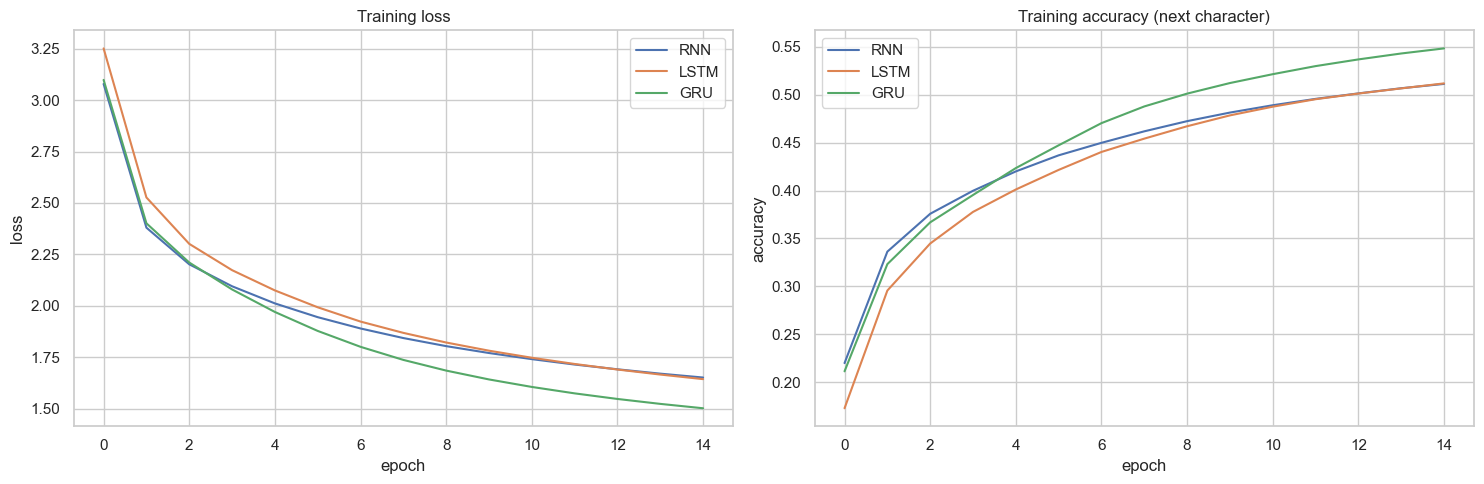

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for kind in ['RNN', 'LSTM', 'GRU']:
    axes[0].plot(histories[kind]['loss'], label=kind)
    axes[1].plot(histories[kind]['accuracy'], label=kind)
axes[0].set_title('Training loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[1].set_title('Training accuracy (next character)'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

In [10]:
import pandas as pd
summary = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Final loss': [histories[k]['loss'][-1] for k in ['RNN','LSTM','GRU']],
    'Final accuracy': [histories[k]['accuracy'][-1] for k in ['RNN','LSTM','GRU']],
    'Train time (s)': [train_time[k] for k in ['RNN','LSTM','GRU']],
}).round(3)
summary

,Model,Final loss,Final accuracy,Train time (s)
0,RNN,1.652,0.511,158.239
1,LSTM,1.644,0.512,535.545
2,GRU,1.503,0.548,413.009


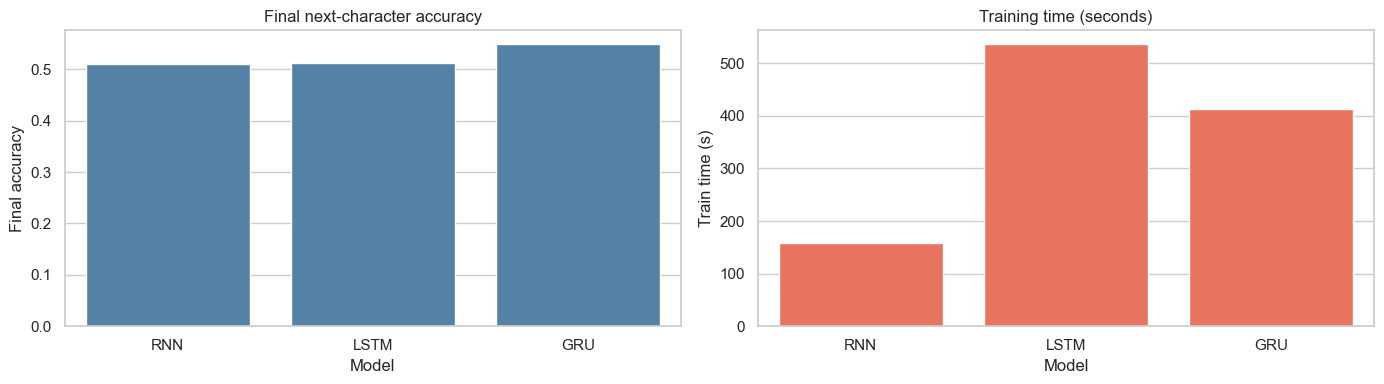

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=summary, x='Model', y='Final accuracy', ax=axes[0], color='steelblue')
axes[0].set_title('Final next-character accuracy')
sns.barplot(data=summary, x='Model', y='Train time (s)', ax=axes[1], color='tomato')
axes[1].set_title('Training time (seconds)')
plt.tight_layout(); plt.show()

## 8. Generating text

To generate text I give the model a short seed string and then repeatedly ask it for the next
character. Each step I take the model's scores for the next character, divide them by a
temperature, and sample from that distribution:

- low temperature (like 0.2) makes it play safe and repetitive
- around 0.7 to 1.0 is more creative but can make more mistakes

I feed back the last 100 characters as context each step.

In [12]:
def generate_text(model, seed, num_generate=500, temperature=0.7):
    # keep only characters the model knows
    seed = ''.join(c for c in seed if c in char2idx)
    idx = [char2idx[c] for c in seed]
    out = list(seed)
    for _ in range(num_generate):
        context = idx[-SEQ_LEN:]
        inp = tf.expand_dims(context, 0)
        logits = model(inp, training=False)[0, -1] / temperature
        next_id = int(tf.random.categorical(tf.expand_dims(logits, 0), 1)[0, 0])
        idx.append(next_id)
        out.append(idx2char[next_id])
    return ''.join(out)

In [13]:
seed = 'ROMEO:'
for kind in ['RNN', 'LSTM', 'GRU']:
    print('=' * 70)
    print(kind, 'generated text (temperature 0.7)')
    print('=' * 70)
    print(generate_text(models[kind], seed, num_generate=500, temperature=0.7))
    print()

RNN generated text (temperature 0.7)


ROMEO:
Now so say anter that with a not so some, trancely sever and forthur to this nother;
That sains, the kings under tree the son, I brow a grants therefore conould in this offtered trie:
Will stence op with there you his blain.

DAKE OF YORK:
I have me hath me.

BUCKINGHAM:
Thingoral boding save in the shall have that of him.

DUCHESS OF YORK:
Boht speak lade I his soul I past.

Nurse:
Grother inte mades of him find my cannearous not her
What for these but will them than yet leakn'd blood;
An the 

LSTM generated text (temperature 0.7)


ROMEO:
So, I am ruke is not to the vanterous an your sleakn
Sichage of streets to bariled to well not.
I take the seal to liest common of this men.
Pray trow my forte the with dost is make
In seed have unter this last and coffire
And the with the peilt of yours formberter.

MENENIUS:
If it sweet of news there all of he;
That wat come he from for to the sentiem.

HENRY BOLINGBROKE:
Nay love? I sould as I have therefore.

GLOUCESTER:
Who man; I will not resiom be to sue the are.

JULIET:
That mank's a d

GRU generated text (temperature 0.7)


ROMEO:
There fair eques, thou shopt against exwards may been to the hates
That part fire meen to the say and brood.

SICINIUS:
Farewell see the life of thee.

KING RICHARD III:
Seep the father and well.

DUCHESS OF YORK:
I would the heart meet. What it will not the air a tentoning
Marry of our cannot, by my soul deniments to thee,
With gracious let the will pervant is not stay where is like a benfelf at the a king,
Which a some banish'd will do me love, break should be the set anjorn;
For with fellow 



### 8.1 Effect of temperature

Using the LSTM, here is the same seed generated at three temperatures so the trade off between
safe and creative is easy to see.

In [14]:
for temp in [0.2, 0.7, 1.0]:
    print('-' * 70)
    print('Temperature', temp)
    print('-' * 70)
    print(generate_text(models['LSTM'], 'QUEEN:', num_generate=400, temperature=temp))
    print()

----------------------------------------------------------------------
Temperature 0.2
----------------------------------------------------------------------


QUEEN:
What is the sent the parter and the with a prace.

CORIOLANUS:
I may and the sear the parter of the comes,
And the senter the proper of the prople and the properte
That we have see the was the seep the properted the comest
The sear the seepor the sentle in the parter of the parter,
And the bear the sent to the prought of the prople
That shall be shall be so me the properon the prother
The many an

----------------------------------------------------------------------
Temperature 0.7
----------------------------------------------------------------------


QUEEN:
Musting with the come but be so the can
The brought; with streathing to should of his bege,
And hath could and under us that say will now and been
That know the reeps thy worst wear, and hool unjok?

LADD CAUPET:
Whot we for him so like,
The pront fird and make the loggry to me whet have shall
That say our noble our pracion liegs on the
Sender their crear them answill'd; and there.

Servent:
Tell

----------------------------------------------------------------------
Temperature 1.0
----------------------------------------------------------------------


QUEEN:
So llast wose RAace; he is in blord:
My hadneir live there boordapt it thee orave! Norl.
But gots twith we mine a words, am them.

ROMEO:
My ress mare fear
is poot of friendon hat well requesh
To swert, so, therefolk is clistlanderes, Norfor'
I seal unse best: I ceal wink, yet:
'sofen o't, and they glood a morrout but mu nother to chaimedys
And my well her fate not the thee provain.

OMTARY:
I ma



## Conclusion

What I did and what I found:

1. Loaded the Shakespeare corpus and used the first 600,000 characters (65 unique characters).
2. Turned the text into character sequences where the target is the input shifted by one, so the
   model learns to predict the next character at every position.
3. Trained three recurrent models with the same setup - a vanilla RNN, an LSTM and a GRU.
4. All three learned real structure: they produce actual words, spaces, line breaks, punctuation
   and the play format of a name in capitals followed by a colon, none of which they were told.
5. The GRU came out best, with the lowest loss (about 1.50) and the highest next-character
   accuracy (about 0.55), and its generated text reads the most coherently. The vanilla RNN and
   the LSTM finished close to each other in these 15 epochs (loss about 1.65, accuracy about
   0.51). An LSTM usually needs more epochs to pull clearly ahead of a vanilla RNN, so with a
   longer training run I would expect it to keep improving.
6. The temperature demo shows the usual trade off - low temperature is repetitive and safe, while
   higher temperature is more varied but makes more spelling and grammar slips.

### Model selection conclusion

For this corpus and this training budget the GRU was the best choice: it reached the lowest loss
and the highest accuracy, and it trained faster than the LSTM because it has fewer gates and
fewer parameters. The vanilla RNN was the weakest and, as expected for such a simple recurrent
layer, produced the least coherent text. The LSTM landed between them here - it is a strong model
but needs more epochs to show its full advantage. So my pick for this setup is the GRU, with the
LSTM as the model I would come back to if I could train for longer.

### What worked

- Character level modeling with a next character target: simple and effective, with no hand
  written grammar rules needed.
- Gated recurrent layers, especially the GRU: lower loss and more coherent text than the vanilla
  RNN.
- Temperature sampling: an easy dial to trade off between safe and creative output.

### Future enhancements

- Train for more epochs on a GPU and on the full corpus, which would sharpen the grammar further
  and likely let the LSTM catch up to or pass the GRU.
- Stack two recurrent layers and add dropout for more capacity without overfitting.
- Move from character level to word level or subword tokens, or fine tune a small pretrained
  Transformer, which would produce much more fluent text.